<a href="https://colab.research.google.com/github/bertramwooster/deep-learning-with-python-notebooks/blob/my-notebook-experiments/chapter03_introduction-to-ml-frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Introduction to TensorFlow, PyTorch, JAX, and Keras

### A brief history of deep learning frameworks

### How these frameworks relate to each other

### Introduction to TensorFlow

#### First steps with TensorFlow

##### Tensors and variables in TensorFlow

###### Constant tensors

In [4]:
import tensorflow as tf
tf.ones(shape=(2, 1))

2025-09-29 04:20:53.003560: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-29 04:20:53.180354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759119653.241836    1677 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759119653.258705    1677 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759119653.400748    1677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [5]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [6]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

In [7]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[ 1.7450585 ]
 [-0.9268978 ]
 [ 0.51135725]], shape=(3, 1), dtype=float32)


In [8]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.11034977]
 [0.10768878]
 [0.84719515]], shape=(3, 1), dtype=float32)


In [9]:
# tf.random.uniform can be used to generate random integers by specifying an integer dtype
tf.random.uniform(shape=(3, 2, 2), minval=0, maxval=10, dtype=tf.int32)

<tf.Tensor: shape=(3, 2, 2), dtype=int32, numpy=
array([[[9, 2],
        [7, 7]],

       [[8, 6],
        [0, 0]],

       [[8, 7],
        [6, 7]]], dtype=int32)>

###### Tensor assignment and the Variable class

In [ ]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [ ]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.3941398 ],
       [-0.32681444],
       [-0.08987077]], dtype=float32)>


In [ ]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

In [ ]:
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>


##### Tensor operations: Doing math in TensorFlow

In [ ]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=1)
print(f)

tf.Tensor(
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]], shape=(2, 4), dtype=float32)


In [ ]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [ ]:
a = tf.constant(range(1,7), shape = (2,3))
b = tf.constant(range(1,7), shape = (3,2))
print(a)
print(b)
c = tf.matmul(a,b)
print(c)

tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)
tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)
tf.Tensor(
[[22 28]
 [49 64]], shape=(2, 2), dtype=int32)


In [ ]:
print(dense(tf.constant([[1.]]), tf.constant([[1., -1., 0.]]),
      tf.constant([[1., 1., 1.]])))

tf.Tensor([[2. 0. 1.]], shape=(1, 3), dtype=float32)


##### Gradients in TensorFlow: A second look at the GradientTape API

In [ ]:
input_var = tf.Variable(initial_value=13.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
print(gradient.numpy())

26.0


In [ ]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [ ]:
time = tf.Variable(1.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)
print(f'At time = {time.numpy()} s, v = {speed.numpy():.2f} m/s \
and a = {acceleration.numpy():.2f} m/s**2')

At time = 1.0 s, v = 9.80 m/s and a = 9.80 m/s**2


##### Making TensorFlow functions fast using compilation

In [ ]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [ ]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure TensorFlow

In [48]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [49]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [60]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

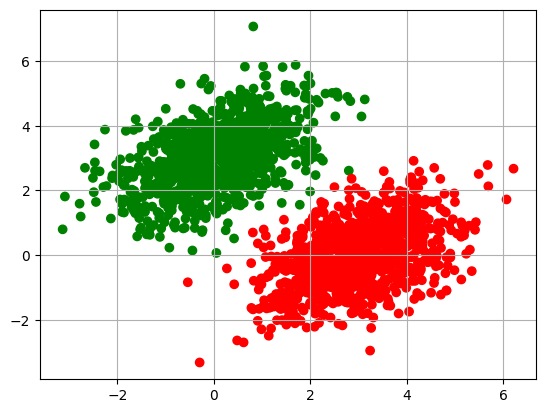

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Create a list of colors based on the targets
colors = np.where(targets[:, 0] == 0, 'green', 'red')

plt.scatter(inputs[:, 0], inputs[:, 1], c=colors)
plt.grid(True)
plt.show()

In [ ]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [ ]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [ ]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [ ]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [ ]:
loss = []
for step in range(40):
    loss.append(training_step(inputs, targets, W, b))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 5.9083
Loss at step 1: 0.8127
Loss at step 2: 0.2390
Loss at step 3: 0.1520
Loss at step 4: 0.1320
Loss at step 5: 0.1217
Loss at step 6: 0.1134
Loss at step 7: 0.1060
Loss at step 8: 0.0992
Loss at step 9: 0.0930
Loss at step 10: 0.0873
Loss at step 11: 0.0821
Loss at step 12: 0.0773
Loss at step 13: 0.0729
Loss at step 14: 0.0689
Loss at step 15: 0.0653
Loss at step 16: 0.0619
Loss at step 17: 0.0588
Loss at step 18: 0.0560
Loss at step 19: 0.0535
Loss at step 20: 0.0511
Loss at step 21: 0.0489
Loss at step 22: 0.0470
Loss at step 23: 0.0452
Loss at step 24: 0.0435
Loss at step 25: 0.0420
Loss at step 26: 0.0406
Loss at step 27: 0.0393
Loss at step 28: 0.0382
Loss at step 29: 0.0371
Loss at step 30: 0.0361
Loss at step 31: 0.0352
Loss at step 32: 0.0344
Loss at step 33: 0.0337
Loss at step 34: 0.0330
Loss at step 35: 0.0323
Loss at step 36: 0.0318
Loss at step 37: 0.0312
Loss at step 38: 0.0308
Loss at step 39: 0.0303


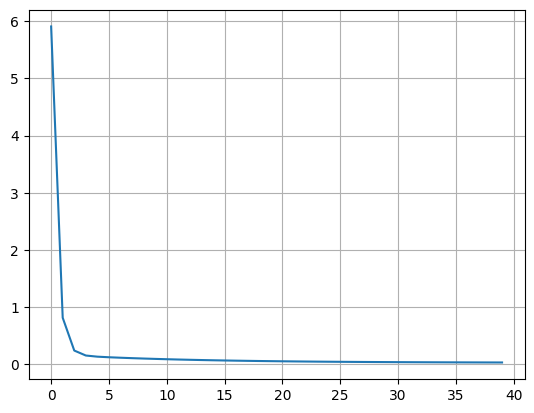

In [ ]:
from matplotlib import pyplot as plt
plt.plot(loss)
plt.grid()
plt.show()

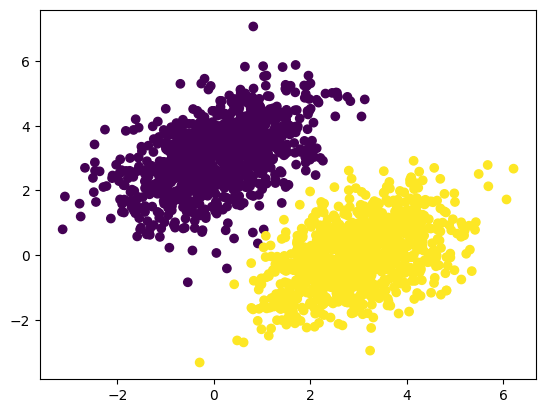

In [ ]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

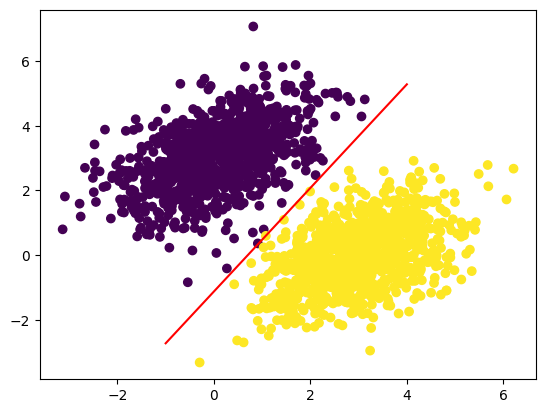

In [ ]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### What makes the TensorFlow approach unique

### Introduction to PyTorch

#### First steps with PyTorch

##### Tensors and parameters in PyTorch

###### Constant tensors

In [4]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [5]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [8]:
torch.tensor(range(6), dtype=torch.float32).reshape(3, 2)

tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])

###### Random tensors

In [10]:
torch.normal(mean=torch.zeros(size=(3, 1)),
             std=torch.ones(size=(3, 1)))

tensor([[ 1.2504],
        [ 0.3145],
        [-1.7682]])

In [14]:
# Mean of the distribution
mean = torch.zeros(2)

# Covariance matrix for a bivariate normal distribution with correlation 0.5
# The diagonal elements are the variances (here set to 1), and the off-diagonal
# elements are the covariances (correlation * sqrt(variance1 * variance2) = 0.5 * sqrt(1*1) = 0.5)
covariance_matrix = torch.tensor([[1.0, 0.5],
                                  [0.5, 1.0]])

# Create the multivariate normal distribution
m = torch.distributions.MultivariateNormal(mean, covariance_matrix)

# Generate 10 samples
samples = m.sample((3, ))
print(samples)

tensor([[-1.2561,  0.4729],
        [-0.4724, -0.0869],
        [-0.3549,  0.1761]])


In [17]:
torch.rand(3, 1)

tensor([[0.8464],
        [0.6870],
        [0.4538]])

###### Tensor assignment and the Parameter class

In [18]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [19]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### Tensor operations: Doing math in PyTorch

In [20]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

In [21]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

In [35]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

In [39]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(30.)

In [33]:
input_var.grad = None

#### An end-to-end example: A linear classifier in pure PyTorch

In [68]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [56]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [57]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [63]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

In [69]:
loss = []
torch_inputs = torch.tensor(inputs)
torch_targets = torch.tensor(targets)
for step in range(40):
    loss.append(training_step(torch_inputs, torch_targets, W, b))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 1.8399
Loss at step 1: 0.3214
Loss at step 2: 0.1432
Loss at step 3: 0.1131
Loss at step 4: 0.1030
Loss at step 5: 0.0960
Loss at step 6: 0.0899
Loss at step 7: 0.0844
Loss at step 8: 0.0794
Loss at step 9: 0.0747
Loss at step 10: 0.0705
Loss at step 11: 0.0667
Loss at step 12: 0.0632
Loss at step 13: 0.0599
Loss at step 14: 0.0570
Loss at step 15: 0.0543
Loss at step 16: 0.0519
Loss at step 17: 0.0496
Loss at step 18: 0.0476
Loss at step 19: 0.0457
Loss at step 20: 0.0440
Loss at step 21: 0.0424
Loss at step 22: 0.0410
Loss at step 23: 0.0397
Loss at step 24: 0.0385
Loss at step 25: 0.0374
Loss at step 26: 0.0364
Loss at step 27: 0.0354
Loss at step 28: 0.0346
Loss at step 29: 0.0338
Loss at step 30: 0.0331
Loss at step 31: 0.0325
Loss at step 32: 0.0319
Loss at step 33: 0.0314
Loss at step 34: 0.0309
Loss at step 35: 0.0305
Loss at step 36: 0.0301
Loss at step 37: 0.0297
Loss at step 38: 0.0293
Loss at step 39: 0.0290


##### Packaging state and computation with the Module class

In [88]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [89]:
model = LinearModel()

In [90]:
#torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [91]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [92]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

In [93]:
loss = []
for step in range(40):
    loss.append(training_step(torch_inputs, torch_targets))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 4.3097
Loss at step 1: 0.6415
Loss at step 2: 0.2081
Loss at step 3: 0.1426
Loss at step 4: 0.1260
Loss at step 5: 0.1165
Loss at step 6: 0.1086
Loss at step 7: 0.1015
Loss at step 8: 0.0949
Loss at step 9: 0.0890
Loss at step 10: 0.0836
Loss at step 11: 0.0786
Loss at step 12: 0.0740
Loss at step 13: 0.0699
Loss at step 14: 0.0661
Loss at step 15: 0.0626
Loss at step 16: 0.0594
Loss at step 17: 0.0566
Loss at step 18: 0.0539
Loss at step 19: 0.0515
Loss at step 20: 0.0493
Loss at step 21: 0.0472
Loss at step 22: 0.0454
Loss at step 23: 0.0437
Loss at step 24: 0.0422
Loss at step 25: 0.0407
Loss at step 26: 0.0395
Loss at step 27: 0.0383
Loss at step 28: 0.0372
Loss at step 29: 0.0362
Loss at step 30: 0.0353
Loss at step 31: 0.0345
Loss at step 32: 0.0337
Loss at step 33: 0.0330
Loss at step 34: 0.0324
Loss at step 35: 0.0318
Loss at step 36: 0.0313
Loss at step 37: 0.0308
Loss at step 38: 0.0304
Loss at step 39: 0.0300


##### Making PyTorch modules fast using compilation

In [53]:
compiled_model = torch.compile(model)

In [54]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### What makes the PyTorch approach unique

### Introduction to JAX

#### First steps with JAX

#### Tensors in JAX

In [10]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [11]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [15]:
jnp.full(shape=(2, 1), fill_value = .2)

Array([[0.2],
       [0.2]], dtype=float32, weak_type=True)

In [ ]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### Random number generation in JAX

In [16]:
import numpy as np
np.random.normal(size=(3,))

array([-1.81436069,  1.46737319,  0.3777147 ])

In [17]:
np.random.normal(size=(3,))

array([ 0.75321623,  0.81494469, -1.94372609])

In [19]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
x = np.random.normal(size=(3,))
y = apply_noise(x, seed)
seed += 0
z = apply_noise(x, seed)
print(x,y,z)

[ 0.06905289 -1.36994721 -1.73542443] [ 0.15860155 -3.14651214 -3.98594485] [ 0.15860155 -3.14651214 -3.98594485]


In [20]:
import jax

seed_key = jax.random.key(1337)

In [23]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [24]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [25]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [26]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [33]:
new_seed_key_list = jax.random.split(seed_key, num=6)#[0]
#jax.random.normal(new_seed_key, shape=(3,))
print(len(new_seed_key_list))
for new_seed_key in new_seed_key_list:
    print()
    print(jax.random.normal(new_seed_key, shape=(3,)))

6

[-0.49093357 -0.9478693  -1.775197  ]

[-0.7828054 -1.5373377 -0.5513038]

[-0.9033962  1.0895388 -1.1968036]

[2.4205756 0.1779215 0.5011102]

[ 0.52137166 -0.1863865   1.2542883 ]

[ 0.69527596 -0.5525624  -1.2247187 ]


In [32]:
type(new_seed_key_list)

jax._src.prng.PRNGKeyArray

##### Tensor assignment

In [34]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)
new_x

Array([10.,  2.,  3.], dtype=float32)

##### Tensor operations: Doing math in JAX

In [35]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [36]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

In [37]:
def compute_loss(input_var):
    return jnp.square(input_var)

In [38]:
grad_fn = jax.grad(compute_loss)

In [39]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX gradient-computation best practices

###### Returning the loss value

In [42]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

###### Getting gradients for a complex function

###### Returning auxiliary outputs

##### Making JAX functions fast with @jax.jit

In [41]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure JAX

In [ ]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [ ]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [ ]:
grad_fn = jax.value_and_grad(compute_loss)

In [ ]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [ ]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

#### What makes the JAX approach unique

### Introduction to Keras

#### First steps with Keras

##### Picking a backend framework

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### Layers: The building blocks of deep learning

##### The base `Layer` class in Keras

In [ ]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [ ]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

##### Automatic shape inference: Building layers on the fly

In [ ]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [ ]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [ ]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### From layers to models

#### The "compile" step: Configuring the learning process

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [ ]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### Picking a loss function

#### Understanding the fit method

In [ ]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

In [ ]:
history.history

#### Monitoring loss and metrics on validation data

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

#### Inference: Using a model after training

In [ ]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])